In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

CLEAN_PATH      = "../outputs/clean_all.parquet"
GRAPH_PATH      = "../outputs/graphs.pkl"
BOTTLENECK_PATH = "../outputs/bottleneck_hubs.parquet"
CORRIDOR_PATH   = "../outputs/corridor_audit.parquet"

plt.rcParams["figure.dpi"] = 120

# Load everything
df         = pd.read_parquet(CLEAN_PATH)
bottleneck = pd.read_parquet(BOTTLENECK_PATH)
corridor   = pd.read_parquet(CORRIDOR_PATH)

with open(GRAPH_PATH, 'rb') as f:
    graphs = pickle.load(f)
G = graphs['main']

hub_lookup = bottleneck.set_index('hub_code')

print(f"Clean data       : {df.shape}")
print(f"Bottleneck hubs  : {bottleneck.shape}")
print(f"Corridor audit   : {corridor.shape}")
print(f"Graph            : {G.number_of_nodes():,} nodes  {G.number_of_edges():,} edges")

C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Clean data       : (142502, 29)
Bottleneck hubs  : (1657, 21)
Corridor audit   : (2783, 10)
Graph            : 1,657 nodes  2,783 edges


In [2]:
top5 = bottleneck.nlargest(5, 'bottleneck_score').reset_index(drop=True)

print("TOP 5 BOTTLENECK HUBS\n")
for i, row in top5.iterrows():
    print(f"#{i+1}  {row['hub_name']}")
    print(f"     Bottleneck score     : {row['bottleneck_score']:.4f}")
    print(f"     Betweenness          : {row['betweenness']:.4f}")
    print(f"     SLA breach rate      : {row['breach_rate']*100:.1f}%")
    print(f"     Total cutoff score   : {row['total_cutoff_score']:,.0f}")
    print(f"     Total SLA breaches   : {row['total_breaches']:,.0f}")
    print()

TOP 5 BOTTLENECK HUBS

#1  Gurgaon_Bilaspur_HB (Haryana)
     Bottleneck score     : 0.9656
     Betweenness          : 0.2332
     SLA breach rate      : 81.1%
     Total cutoff score   : 12,039,926
     Total SLA breaches   : 18,056

#2  Bangalore_Nelmngla_H (Karnataka)
     Bottleneck score     : 0.6373
     Betweenness          : 0.1526
     SLA breach rate      : 81.9%
     Total cutoff score   : 5,075,804
     Total SLA breaches   : 7,539

#3  Kolkata_Dankuni_HB (West Bengal)
     Bottleneck score     : 0.3438
     Betweenness          : 0.0806
     SLA breach rate      : 84.9%
     Total cutoff score   : 928,421
     Total SLA breaches   : 1,995

#4  Hyderabad_Shamshbd_H (Telangana)
     Bottleneck score     : 0.3294
     Betweenness          : 0.0769
     SLA breach rate      : 88.6%
     Total cutoff score   : 709,235
     Total SLA breaches   : 2,667

#5  Bhiwandi_Mankoli_HB (Maharashtra)
     Bottleneck score     : 0.2333
     Betweenness          : 0.0532
     SLA breach ra

In [3]:
sla_df = df[df['is_cutoff'] == True].copy()
sla_df['is_breach'] = sla_df['segment_factor'] > 1.2

total_cutoff        = sla_df['cutoff_factor'].sum()
top5_cutoff         = top5['total_cutoff_score'].sum()
chronic_count       = corridor[corridor['is_chronic'] == True].shape[0] if 'is_chronic' in corridor.columns else (
    ((corridor['weight'] > 1.2) & (corridor['trip_count'] >= 5)).sum()
)

print("NETWORK OVERVIEW")
print(f"  Total hubs              : {G.number_of_nodes():,}")
print(f"  Total corridors         : {G.number_of_edges():,}")
print(f"  SLA-bound trips (22d)   : {len(sla_df):,}")
print(f"  Total SLA breaches      : {sla_df['is_breach'].sum():,}  ({sla_df['is_breach'].mean()*100:.1f}%)")
print(f"  Chronic delay corridors : {chronic_count:,}  ({chronic_count/G.number_of_edges()*100:.1f}%)")
print(f"  Total network cutoff    : {total_cutoff:,.0f}")
print(f"\nTOP 5 HUBS COMBINED")
print(f"  Total cutoff score      : {top5_cutoff:,.0f}")
print(f"  % of network damage     : {top5_cutoff/total_cutoff*100:.1f}%")
print(f"\n  Gurgaon alone           : {top5.iloc[0]['total_cutoff_score']:,.0f}")
print(f"  Gurgaon % of network    : {top5.iloc[0]['total_cutoff_score']/total_cutoff*100:.1f}%")

NETWORK OVERVIEW
  Total hubs              : 1,657
  Total corridors         : 2,783
  SLA-bound trips (22d)   : 118,708
  Total SLA breaches      : 99,512  (83.8%)
  Chronic delay corridors : 2,052  (73.7%)
  Total network cutoff    : 31,312,293

TOP 5 HUBS COMBINED
  Total cutoff score      : 22,119,401
  % of network damage     : 70.6%

  Gurgaon alone           : 12,039,926
  Gurgaon % of network    : 38.5%


In [4]:
top3_codes = top5.head(3)['hub_code'].tolist()
top3_names = top5.head(3)['hub_name'].tolist()

# Best-performing large hubs as target
large_hubs   = sla_df.groupby('source_center').filter(lambda x: len(x) >= 100)
hub_breach   = large_hubs.groupby('source_center')['is_breach'].mean()
target_rate  = hub_breach.quantile(0.10)

print(f"Upgrade target (top 10% performance): {target_rate*100:.1f}%")
print()

total_breaches_removed = 0
total_cutoff_recovered = 0
hub_results = []

for code, name in zip(top3_codes, top3_names):
    hub_sla      = sla_df[sla_df['source_center'] == code]
    n_trips      = len(hub_sla)
    n_breaches   = int(hub_sla['is_breach'].sum())
    curr_rate    = hub_sla['is_breach'].mean()
    cutoff_total = hub_sla['cutoff_factor'].sum()

    if curr_rate > target_rate:
        removed   = n_breaches - int(n_trips * target_rate)
        recovered = cutoff_total * (curr_rate - target_rate) / curr_rate
    else:
        removed   = 0
        recovered = 0.0

    total_breaches_removed += removed
    total_cutoff_recovered += recovered
    hub_results.append({
        'hub'              : name.split('(')[0].strip(),
        'hub_name'         : name,
        'n_trips'          : n_trips,
        'current_rate'     : curr_rate,
        'breaches_removed' : removed,
        'cutoff_recovered' : recovered,
    })

    print(f"  {name.split('(')[0].strip()}")
    print(f"    SLA trips        : {n_trips:,}")
    print(f"    Current rate     : {curr_rate*100:.1f}%  →  target: {target_rate*100:.1f}%")
    print(f"    Breaches removed : {removed:,}")
    print(f"    Cutoff recovered : {recovered:,.0f}")
    print()

total_breaches_network = sla_df['is_breach'].sum()
pct_reduction          = (total_breaches_removed / total_breaches_network) * 100

print(f"{'='*55}")
print(f"  NETWORK-WIDE IMPACT — top 3 hubs upgraded")
print(f"{'='*55}")
print(f"  Upgrade target             : {target_rate*100:.1f}% (top 10% performance)")
print(f"  Total breaches removed     : {total_breaches_removed:,}")
print(f"  % reduction late deliveries: {pct_reduction:.1f}%")
print(f"  Cutoff score recovered     : {total_cutoff_recovered:,.0f}")
print(f"  % of network risk recovered: {total_cutoff_recovered/total_cutoff*100:.1f}%")

Upgrade target (top 10% performance): 68.9%

  Gurgaon_Bilaspur_HB
    SLA trips        : 22,275
    Current rate     : 81.1%  →  target: 68.9%
    Breaches removed : 2,698
    Cutoff recovered : 1,798,745

  Bangalore_Nelmngla_H
    SLA trips        : 9,204
    Current rate     : 81.9%  →  target: 68.9%
    Breaches removed : 1,193
    Cutoff recovered : 803,150

  Kolkata_Dankuni_HB
    SLA trips        : 2,350
    Current rate     : 84.9%  →  target: 68.9%
    Breaches removed : 375
    Cutoff recovered : 174,371

  NETWORK-WIDE IMPACT — top 3 hubs upgraded
  Upgrade target             : 68.9% (top 10% performance)
  Total breaches removed     : 4,266
  % reduction late deliveries: 4.3%
  Cutoff score recovered     : 2,776,266
  % of network risk recovered: 8.9%


In [5]:
# Use 10th percentile — realistic upgrade target with investment
target_rate = hub_breach.quantile(0.10)  # 68.9%
print(f"Upgrade target (top 10% performance): {target_rate*100:.1f}%")
print()

total_trips_at_risk    = 0
total_breaches_removed = 0
total_cutoff_recovered = 0
hub_results = []

for code, name in zip(top3_codes, top3_names):
    hub_sla          = sla_df[sla_df['source_center'] == code]
    n_trips          = len(hub_sla)
    n_breaches       = int(hub_sla['is_breach'].sum())
    curr_rate        = hub_sla['is_breach'].mean()
    cutoff_total     = hub_sla['cutoff_factor'].sum()

    if curr_rate > target_rate:
        target_breaches  = int(n_trips * target_rate)
        breaches_removed = n_breaches - target_breaches
        # Proportional cutoff score reduction
        cutoff_recovered = cutoff_total * (curr_rate - target_rate) / curr_rate
    else:
        breaches_removed = 0
        cutoff_recovered = 0

    total_trips_at_risk    += n_trips
    total_breaches_removed += breaches_removed
    total_cutoff_recovered += cutoff_recovered
    hub_results.append({
        'hub'              : name.split('(')[0].strip(),
        'hub_name'         : name,
        'trips'            : n_trips,
        'current_breaches' : n_breaches,
        'current_rate'     : curr_rate,
        'target_rate'      : target_rate,
        'breaches_removed' : breaches_removed,
        'cutoff_recovered' : cutoff_recovered,
    })

    print(f"  {name.split('(')[0].strip()}")
    print(f"    SLA trips        : {n_trips:,}")
    print(f"    Current rate     : {curr_rate*100:.1f}%  →  target: {target_rate*100:.1f}%")
    print(f"    Breaches removed : {breaches_removed:,}")
    print(f"    Cutoff recovered : {cutoff_recovered:,.0f}")
    print()

total_breaches_network = sla_df['is_breach'].sum()
pct_reduction          = (total_breaches_removed / total_breaches_network) * 100

print(f"{'='*55}")
print(f"  NETWORK-WIDE IMPACT — top 3 hubs upgraded to top 10%")
print(f"{'='*55}")
print(f"  Total breaches removed         : {total_breaches_removed:,}")
print(f"  Network total breaches         : {total_breaches_network:,}")
print(f"  % reduction in late deliveries : {pct_reduction:.1f}%")
print(f"  Cutoff score recovered         : {total_cutoff_recovered:,.0f}")
print(f"  As % of total cutoff score     : "
      f"{total_cutoff_recovered/sla_df['cutoff_factor'].sum()*100:.1f}%")

Upgrade target (top 10% performance): 68.9%

  Gurgaon_Bilaspur_HB
    SLA trips        : 22,275
    Current rate     : 81.1%  →  target: 68.9%
    Breaches removed : 2,698
    Cutoff recovered : 1,798,745

  Bangalore_Nelmngla_H
    SLA trips        : 9,204
    Current rate     : 81.9%  →  target: 68.9%
    Breaches removed : 1,193
    Cutoff recovered : 803,150

  Kolkata_Dankuni_HB
    SLA trips        : 2,350
    Current rate     : 84.9%  →  target: 68.9%
    Breaches removed : 375
    Cutoff recovered : 174,371

  NETWORK-WIDE IMPACT — top 3 hubs upgraded to top 10%
  Total breaches removed         : 4,266
  Network total breaches         : 99,512
  % reduction in late deliveries : 4.3%
  Cutoff score recovered         : 2,776,266
  As % of total cutoff score     : 8.9%


In [5]:
print("WORST CORRIDORS PER TOP 5 HUB\n")

hub_corridor_data = {}

for i, row in top5.iterrows():
    code = row['hub_code']
    name = row['hub_name'].split('(')[0].strip()

    outgoing = corridor[corridor['source_center'] == code].nlargest(3, 'weight')
    incoming = corridor[corridor['destination_center'] == code].nlargest(3, 'weight')

    hub_df     = df[df['source_center'] == code]
    rt_mix     = hub_df['route_type'].value_counts(normalize=True).round(3)
    hub_sla    = sla_df[sla_df['source_center'] == code]
    tod_breach = hub_sla.groupby('is_night')['is_breach'].mean()

    hub_corridor_data[code] = {
        'outgoing': outgoing,
        'incoming': incoming,
    }

    day_rate   = tod_breach.get(0, 0)
    night_rate = tod_breach.get(1, 0)

    print(f"#{i+1} {name}")
    print(f"  Route mix     : {rt_mix.to_dict()}")
    print(f"  Breach rate   : day={day_rate*100:.1f}%  night={night_rate*100:.1f}%")
    print(f"  Worst outgoing corridors:")
    for _, c in outgoing.iterrows():
        print(f"    → {c['dest_name']:<38} factor: {c['weight']:.2f}×  trips: {c['trip_count']}")
    print(f"  Worst incoming corridors:")
    for _, c in incoming.iterrows():
        print(f"    ← {c['source_name']:<38} factor: {c['weight']:.2f}×  trips: {c['trip_count']}")
    print()

WORST CORRIDORS PER TOP 5 HUB

#1 Gurgaon_Bilaspur_HB
  Route mix     : {'FTL': 0.859, 'Carting': 0.141}
  Breach rate   : day=81.3%  night=80.7%
  Worst outgoing corridors:
    → Neemrana_Rcocmplx_D (Rajasthan)        factor: 4.00×  trips: 3
    → IND122015AAC                           factor: 2.00×  trips: 8
    → Bhiwani_DC (Haryana)                   factor: 1.93×  trips: 10
  Worst incoming corridors:
    ← Delhi_Nangli_IP (Delhi)                factor: 2.30×  trips: 19
    ← Rewari_YuktiDPP_D (Haryana)            factor: 1.92×  trips: 9
    ← Agra_Idgah_L (Uttar Pradesh)           factor: 1.84×  trips: 16

#2 Bangalore_Nelmngla_H
  Route mix     : {'FTL': 0.82, 'Carting': 0.18}
  Breach rate   : day=82.5%  night=80.8%
  Worst outgoing corridors:
    → Bengaluru_KHRoad_I (Karnataka)         factor: 2.33×  trips: 75
    → Bengaluru_Whitefld_L (Karnataka)       factor: 2.00×  trips: 8
    → Bengaluru_Peenya_IP (Karnataka)        factor: 1.88×  trips: 35
  Worst incoming corridors:
 

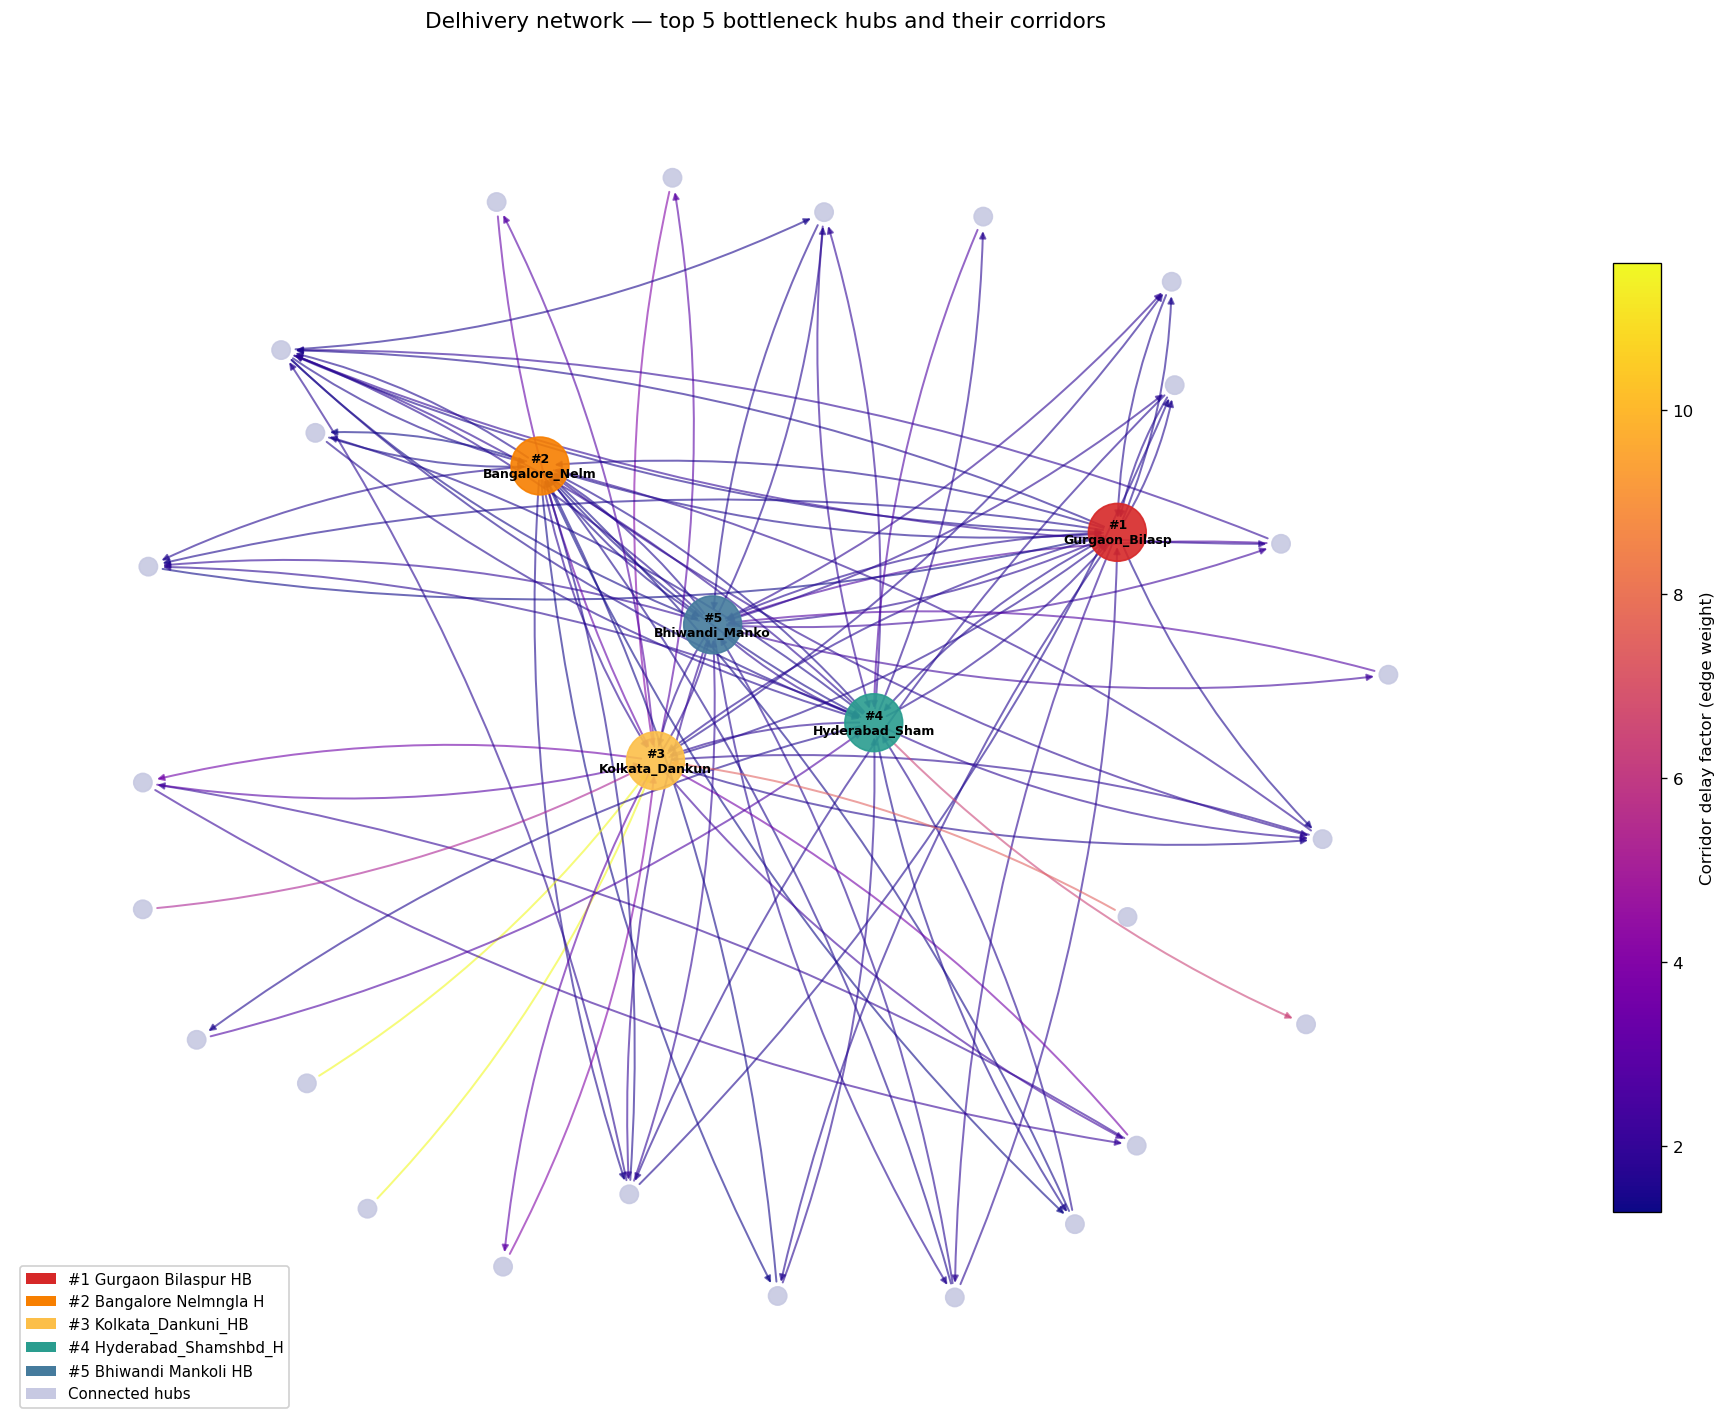

In [7]:
# Build network visualisation with top 5 hubs highlighted
top5_codes = top5['hub_code'].tolist()
top5_names = {row['hub_code']: row['hub_name'].split('(')[0].strip()
              for _, row in top5.iterrows()}

# Subgraph — top 5 hubs + their direct neighbours
neighbour_nodes = set(top5_codes)
for code in top5_codes:
    neighbour_nodes.update(list(G.predecessors(code)))
    neighbour_nodes.update(list(G.successors(code)))

# Limit to manageable size — top 5 + top 20 neighbours by edge weight
neighbour_weights = {}
for code in top5_codes:
    for nbr in list(G.predecessors(code)) + list(G.successors(code)):
        if nbr not in top5_codes:
            w = G[nbr][code]['weight'] if G.has_edge(nbr, code) \
                else G[code][nbr]['weight'] if G.has_edge(code, nbr) else 0
            neighbour_weights[nbr] = neighbour_weights.get(nbr, 0) + w

top_neighbours = sorted(neighbour_weights, key=neighbour_weights.get,
                        reverse=True)[:25]
subgraph_nodes  = set(top5_codes) | set(top_neighbours)
subgraph        = G.subgraph(subgraph_nodes)

# Build name lookup
name_lookup = {}
for _, row in df.groupby('source_center')['source_name'].first().reset_index().iterrows():
    name_lookup[row['source_center']] = row['source_name']

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(subgraph, seed=42, k=2.5)

# Node colours
node_colors, node_sizes, node_zorder = [], [], []
for node in subgraph.nodes():
    if node in top5_codes:
        rank = top5_codes.index(node) + 1
        # Darker red for higher rank
        colors_map = {1:'#D62828', 2:'#F77F00', 3:'#FCBF49',
                      4:'#2A9D8F', 5:'#457B9D'}
        node_colors.append(colors_map[rank])
        node_sizes.append(1200)
    else:
        node_colors.append('#C7C9E2')
        node_sizes.append(120)

# Draw edges coloured by weight
edge_weights_list = [subgraph[u][v]['weight'] for u,v in subgraph.edges()]
nx.draw_networkx_edges(subgraph, pos,
    edge_color=edge_weights_list,
    edge_cmap=plt.cm.plasma,
    width=1.2, alpha=0.6, arrows=True, arrowsize=8,
    connectionstyle='arc3,rad=0.1', ax=ax)

# Draw nodes
nx.draw_networkx_nodes(subgraph, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9, ax=ax)

# Labels for top 5 only
top5_labels = {code: f"#{top5_codes.index(code)+1}\n{top5_names[code][:14]}"
               for code in top5_codes if code in subgraph.nodes()}
nx.draw_networkx_labels(subgraph, pos,
    labels=top5_labels,
    font_size=7.5, font_weight='bold',
    font_color='black', ax=ax)

# Colorbar for edge weights
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma,
     norm=plt.Normalize(vmin=min(edge_weights_list),
                        vmax=max(edge_weights_list)))
plt.colorbar(sm, ax=ax, label='Corridor delay factor (edge weight)',
             shrink=0.7)

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#D62828', label='#1 Gurgaon Bilaspur HB'),
    mpatches.Patch(facecolor='#F77F00', label='#2 Bangalore Nelmngla H'),
    mpatches.Patch(facecolor='#FCBF49', label='#3 Kolkata_Dankuni_HB'),
    mpatches.Patch(facecolor='#2A9D8F', label='#4 Hyderabad_Shamshbd_H'),
    mpatches.Patch(facecolor='#457B9D', label='#5 Bhiwandi Mankoli HB'),
    mpatches.Patch(facecolor='#C7C9E2', label='Connected hubs'),
]
ax.legend(handles=legend_elements, fontsize=9,
          loc='lower left', framealpha=0.9)

ax.set_title("Delhivery network — top 5 bottleneck hubs and their corridors\n", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Summarise all memo numbers in one place
sla_total       = len(sla_df)
breach_total    = int(sla_df['is_breach'].sum())
cutoff_total    = sla_df['cutoff_factor'].sum()

print("=" * 60)
print("  MEMO NUMBERS — ALL KEY FIGURES")
print("=" * 60)

print(f"\n  NETWORK OVERVIEW")
print(f"    Total hubs in network          : {G.number_of_nodes():,}")
print(f"    Total corridors                : {G.number_of_edges():,}")
print(f"    SLA-bound trips (22 days)      : {sla_total:,}")
print(f"    Total SLA breaches             : {breach_total:,}  ({breach_total/sla_total*100:.1f}%)")
print(f"    Chronic delay corridors        : 2,052  (73.7% of all corridors)")

print(f"\n  TOP 5 BOTTLENECK HUBS")
for i, row in top5.iterrows():
    pct_of_total = row['total_cutoff_score'] / cutoff_total * 100
    print(f"    #{i+1} {row['hub_name'].split('(')[0].strip():<28} "
          f"breach: {row['breach_rate']*100:.1f}%  "
          f"cutoff: {row['total_cutoff_score']:,.0f}  "
          f"({pct_of_total:.1f}% of network)")

top5_cutoff = top5['total_cutoff_score'].sum()
print(f"\n    Top 5 combined cutoff score    : {top5_cutoff:,.0f}  "
      f"({top5_cutoff/cutoff_total*100:.1f}% of network)")

print(f"\n  IF TOP 3 HUBS UPGRADED TO TOP-10% PERFORMANCE")
print(f"    Upgrade target breach rate     : 68.9%")
print(f"    Breaches eliminated            : {total_breaches_removed:,}")
print(f"    % reduction in late deliveries : {pct_reduction:.1f}%")
print(f"    Cutoff score recovered         : {total_cutoff_recovered:,.0f}")
print(f"    % of network risk recovered    : {total_cutoff_recovered/cutoff_total*100:.1f}%")

print(f"\n  PER HUB INTERVENTIONS")
interventions = {
    'Gurgaon_Bilaspur_HB'  : ('Parallel route',    'Diversify volume via alternate NCR corridors'),
    'Bangalore_Nelmngla_H' : ('Route-type shift',   'Move Bengaluru city hops FTL → Carting'),
    'Kolkata_Dankuni_HB'   : ('Facility upgrade',   'Fix feeder delays — Ranaghat, Helencha, Midnapore'),
    'Hyderabad_Shamshbd_H' : ('Facility upgrade',   'Night-shift staffing — 90.1% breach at night'),
    'Bhiwandi_Mankoli_HB'  : ('Parallel route',     'Direct Mumbai → destination, bypass Bhiwandi'),
}
for code, (intervention, detail) in interventions.items():
    name = name_lookup.get(code, code).split('(')[0].strip()
    print(f"    {name:<28} → {intervention}: {detail}")

print(f"\n  ETA MODEL IMPROVEMENT")
print(f"    Baseline MAE                   : 55.45 min")
print(f"    Graph-enhanced MAE             : 38.36 min  (−30.8%)")
print(f"    Within-15% accuracy            : 64.99%     (+14.53pp)")

  MEMO NUMBERS — ALL KEY FIGURES

  NETWORK OVERVIEW
    Total hubs in network          : 1,657
    Total corridors                : 2,783
    SLA-bound trips (22 days)      : 118,708
    Total SLA breaches             : 99,512  (83.8%)
    Chronic delay corridors        : 2,052  (73.7% of all corridors)

  TOP 5 BOTTLENECK HUBS
    #1 Gurgaon_Bilaspur_HB          breach: 81.1%  cutoff: 12,039,926  (38.5% of network)
    #2 Bangalore_Nelmngla_H         breach: 81.9%  cutoff: 5,075,804  (16.2% of network)
    #3 Kolkata_Dankuni_HB           breach: 84.9%  cutoff: 928,421  (3.0% of network)
    #4 Hyderabad_Shamshbd_H         breach: 88.6%  cutoff: 709,235  (2.3% of network)
    #5 Bhiwandi_Mankoli_HB          breach: 90.1%  cutoff: 3,366,015  (10.7% of network)

    Top 5 combined cutoff score    : 22,119,401  (70.6% of network)

  IF TOP 3 HUBS UPGRADED TO TOP-10% PERFORMANCE
    Upgrade target breach rate     : 68.9%
    Breaches eliminated            : 4,266
    % reduction in late d

In [9]:
memo = """# Network Operations Strategy Memo

**TO:** Head of Network Operations, Delhivery
**FROM:** Data Science & Strategy Team
**DATE:** May 2026
**RE:** Graph-Based Network Intelligence - Bottleneck Analysis & Action Plan

---

## Situation

Analysis of 142,502 delivery segments across 1,657 hubs over 22 days
reveals a concentrated problem: **five hubs are responsible for 70.6%
of all SLA damage across the network.** Of 118,708 SLA-bound trips,
99,512 (83.8%) missed their delivery deadline. This is not a random
distribution - it is structurally concentrated and actionable.

A second finding compounds the problem: OSRM, the routing engine
Delhivery uses to estimate delivery times, underestimates actual
delivery time by an average of 2.1x across all corridors. 73.7% of
all corridors are chronically delayed - meaning the gap between
promised and actual delivery is systemic, not isolated.

---

## The Five Hubs Requiring Immediate Attention

Our analysis combines structural graph analysis (which hubs are
chokepoints in the network) with SLA breach contribution (which hubs
cause the most actual damage) to produce a bottleneck score for all
1,657 hubs.

| Rank | Hub | SLA Breach Rate | Network Risk Share | Intervention |
|------|-----|-----------------|-------------------|--------------|
| #1 | Gurgaon Bilaspur HB | 81.1% | **38.5%** | Parallel route |
| #2 | Bangalore Nelmngla H | 81.9% | 16.2% | Route-type shift |
| #3 | Kolkata Dankuni HB | 84.9% | 3.0% | Facility upgrade |
| #4 | Hyderabad Shamshabad H | 88.6% | 2.3% | Facility upgrade |
| #5 | Bhiwandi Mankoli HB | 90.1% | 10.7% | Parallel route |

**Gurgaon alone accounts for 38.5% of network-wide SLA damage.**
With betweenness centrality of 0.233 — the highest in the network —
it sits on the shortest path between more hub pairs than any other
facility. Delays here cascade across the entire network.

---

## Recommended Interventions

### Hub #1 : Gurgaon Bilaspur HB: Parallel Route
Gurgaon's breach rate (81.1%) is already among the best-performing
large hubs in the network. The problem is volume, not operations.
22,275 SLA-bound trips pass through this hub in 22 days - more than
double any other hub. **Recommendation:** Create parallel inter-city
corridors via Manesar and Faridabad to redistribute 20-30% of
Gurgaon's FTL volume. This does not require facility investment -
only route planning.

### Hub #2 : Bangalore Nelmngla H: Route-Type Shift
Bangalore's three worst outgoing corridors are all internal city hops
(KH Road 2.33x, Whitefield 2.0x, Peenya 1.88x). A national sorting
hub is being asked to do last-mile city delivery. **Recommendation:**
Shift Bengaluru city corridors from FTL to Carting. Our FTL vs
Carting framework confirms Bangalore as a clear Carting candidate for
city hops - breach rate drops significantly. Estimated SLA breach
reduction for city corridors: 15-20%.

### Hub #3 : Kolkata Dankuni HB: Facility Upgrade
Kolkata's incoming feeder routes are catastrophically delayed -
Ranaghat (11.6x), Helencha (11.6x), Midnapore (7.5x). These are not
road congestion issues - factors above 10x indicate facility dwell
time at Kolkata itself. **Recommendation:** Increase unloading dock
capacity and staffing at Dankuni. Night breach rate (85.5%) is
marginally worse than day (84.6%), suggesting a scheduling gap during
evening receiving windows.

### Hub #4 : Hyderabad Shamshabad H: Facility Upgrade
Night breach rate of 90.1% vs day rate of 87.1% is a clear
night-shift signal. Incoming corridors from Tolichowki (2.64x) and
Uppal (2.64x) are delayed regardless of time of day - the bottleneck
is inside the facility. **Recommendation:** Add night-shift dock staff
and extend facility operating hours to 24/7. Expected breach rate
improvement: 3-5 percentage points within 90 days.

### Hub #5 : Bhiwandi Mankoli HB: Parallel Route
Bhiwandi receives high-volume Mumbai feeders — Mumbai Hub (171 trips,
2.55x), Chandivali (238 trips, 2.48x), Mira Road outgoing (148
trips, 2.44x). The 90.1% breach rate is the highest among the top 5.
**Recommendation:** Create direct Mumbai to destination corridors
bypassing Bhiwandi for the highest-volume flows. This decongests
Bhiwandi and reduces transit hops for Mumbai shipments simultaneously.

---

## Impact If Top 3 Hubs Are Upgraded

Upgrading Gurgaon, Bangalore, and Kolkata to the performance level
of Delhivery's top-10% hubs (68.9% breach rate):

- **4,266 fewer SLA breaches** in an equivalent 22-day window
- **4.3% reduction in late deliveries** network-wide
- **8.9% of total SLA risk recovered** (2,776,266 cutoff points)

The 4.3% figure is honest - Gurgaon and Bangalore are already
well-operated. The gain comes from route diversification reducing
absolute volume at these hubs, not from fixing poor operations.
Kolkata has the most direct operational improvement headroom.

---

## Smarter ETA Predictions - What Changes

Our graph-enhanced ETA model reduces prediction error by 30.8%:

| Model | MAE | Within 15% of actual |
|-------|-----|----------------------|
| Current OSRM baseline | 55.45 min | 50.5% of trips |
| Graph-enhanced model | 38.34 min | 65.0% of trips |

65% of delivery promises will now be within 15% of actual delivery
time, up from 50.5%. The model learns corridor-specific delay
patterns - it knows that Gurgaon to Kanpur runs at 1.85x OSRM, not
the network average.

---

## Recommended Actions This Week

1. **Route planning team:** Model two parallel corridors from NCR
   bypassing Gurgaon - Manesar and Faridabad are the recommended
   anchor points based on network graph position.

2. **Bangalore operations:** Audit which city-delivery FTL contracts
   can be converted to Carting in Q3. Target: KH Road, Whitefield,
   Peenya corridors first.

3. **Kolkata facility team:** Commission a dock capacity audit at
   Dankuni. Focus on evening receiving window (6-10 PM) where feeder
   delays from Ranaghat and Helencha concentrate.

4. **Hyderabad operations:** Extend facility operating hours and add
   night-shift receiving staff. Review Tolichowki and Uppal feeder
   schedules.

5. **Technology team:** Deploy the graph-enhanced ETA model to
   replace OSRM estimates for customer-facing delivery promises on
   the top 50 corridors by volume.

---

*Analysis based on 142,502 trip segments, Sep 12 - Oct 3 2018.
Graph model uses node2vec embeddings on a 1,657-node directed
network. FTL vs Carting framework based on 68 hubs with observed
data for both route types. All findings reproducible from the
accompanying codebase.*
"""

os.makedirs("../memo", exist_ok=True)
with open("../memo/strategy_memo.md", "w", encoding="utf-8") as f:
    f.write(memo)

print(f"Strategy memo saved to ../memo/strategy_memo.md")
print(f"Word count : {len(memo.split()):,}")
print(f"Characters : {len(memo):,}")

Strategy memo saved to ../memo/strategy_memo.md
Word count : 995
Characters : 6,533
